# US Flight Delays Analysis
**Dataset:** 2015 US Domestic Flights (5.8M flights)  
**Tools:** Python (pandas, matplotlib, seaborn), SQL, Tableau Story

## Project Goal
This project analyzes 2015 US domestic flight data to answer one key business question:

> **What causes flight delays, and which airlines and airports perform the worst?**

We examine delays by airline, airport, time of day, and cause — then provide actionable recommendations for travelers and airline management.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

flights = pd.read_csv('/Users/siheng/Documents/workspace/flights.csv', low_memory=False)
airlines = pd.read_csv('/Users/siheng/Documents/workspace/airlines.csv')
airports = pd.read_csv('/Users/siheng/Documents/workspace/airports.csv')

print(f"Flights: {flights.shape[0]:,} rows, {flights.shape[1]} columns")
print(f"Airlines: {airlines.shape[0]} rows")
print(f"Airports: {airports.shape[0]} rows")


Flights: 5,819,079 rows, 31 columns
Airlines: 14 rows
Airports: 322 rows


## Section 1: Dataset Overview

The dataset contains 5.8 million domestic flights from 2015. Let's take a quick look at the data structure.


In [2]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


Each row is one flight. Key columns: `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `MONTH`, `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `CANCELLED`, and five delay-cause columns: `AIRLINE_DELAY`, `WEATHER_DELAY`, `AIR_SYSTEM_DELAY`, `LATE_AIRCRAFT_DELAY`, `SECURITY_DELAY`.

---

## Section 2: Data Cleaning


In [3]:
print(flights.isnull().sum())



The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_

In [4]:
# Remove cancelled flights for delay analysis
flights_clean = flights[flights['CANCELLED'] == 0].copy()
flights_clean = flights_clean.dropna(subset=['ARRIVAL_DELAY'])

print(f"Original: {len(flights):,} flights")
print(f"After removing cancelled: {len(flights_clean):,} flights")
print(f"Cancelled flights removed: {len(flights) - len(flights_clean):,}")


Original: 5,819,079 flights
After removing cancelled: 5,714,008 flights
Cancelled flights removed: 105,071


**Cleaning result:** Removed 105,071 cancelled flights. Working dataset: 5,714,008 flights.

---

## Section 3: Key Findings


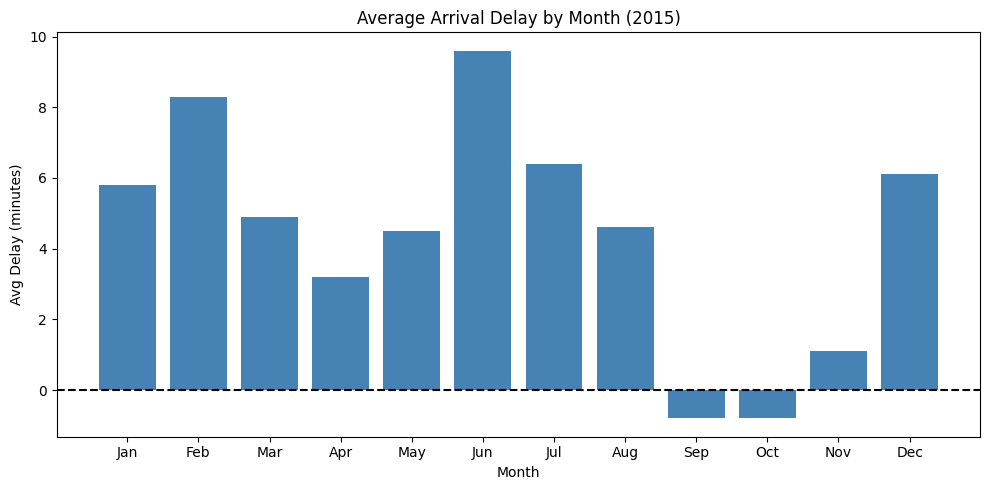

In [5]:
monthly_delay = flights_clean.groupby('MONTH')['ARRIVAL_DELAY'].mean().round(1)

plt.figure(figsize=(10, 5))
plt.bar(monthly_delay.index, monthly_delay.values, color='steelblue')
plt.title('Average Arrival Delay by Month (2015)')
plt.xlabel('Month')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


**Insight:** June is the worst month for delays (avg 9.6 min), driven by summer thunderstorms and peak travel demand. February spikes due to winter storms. September and October are the best months to fly — flights actually arrive early on average.


### Finding 2: Spirit and Frontier Airlines Have the Worst On-Time Performance


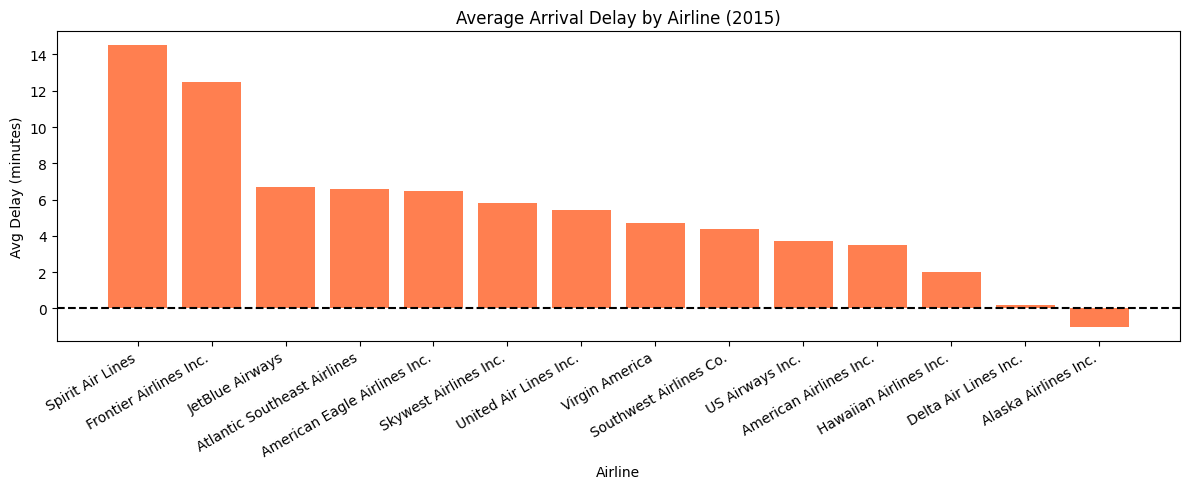

In [6]:
airline_delay = flights_clean.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).round(1)
airline_delay = airline_delay.reset_index()
airline_delay = airline_delay.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')

plt.figure(figsize=(12, 5))
plt.bar(airline_delay['AIRLINE_y'], airline_delay['ARRIVAL_DELAY'], color='coral')
plt.title('Average Arrival Delay by Airline (2015)')
plt.xlabel('Airline')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(rotation=30, ha='right')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


**Insight:** Spirit Air Lines averages 14.5 minutes late — nearly double the industry average. Alaska Airlines is the top performer, arriving slightly early on average. Budget carriers (Spirit, Frontier) consistently underperform legacy carriers.


 ### Finding 3: Airline Issues and Late Aircraft Are the Biggest Delay Causes


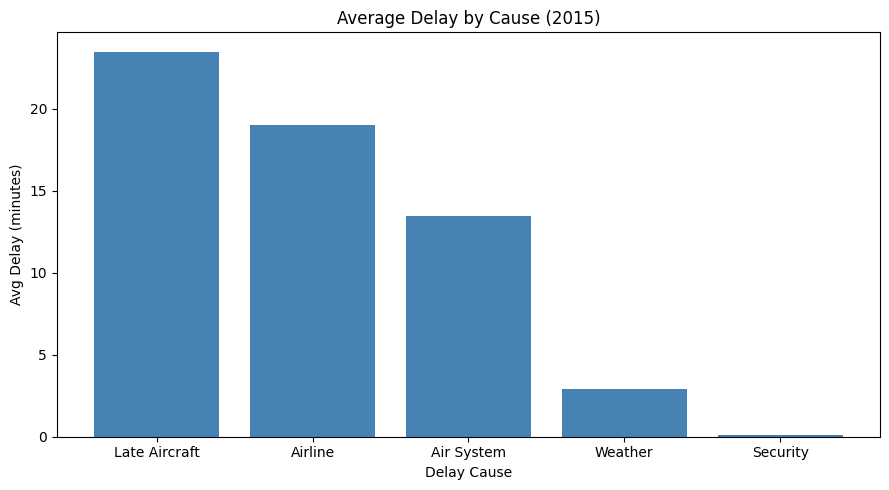

In [7]:
delay_causes = flights_clean[['AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','AIR_SYSTEM_DELAY','WEATHER_DELAY','SECURITY_DELAY']].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(delay_causes.index, delay_causes.values, color='steelblue')
plt.title('Average Delay by Cause (2015)')
plt.xlabel('Delay Cause')
plt.ylabel('Avg Delay (minutes)')
plt.xticks(['AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','AIR_SYSTEM_DELAY','WEATHER_DELAY','SECURITY_DELAY'],
           ['Airline', 'Late Aircraft', 'Air System', 'Weather', 'Security'], rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Late aircraft cascades (23 min avg) are the #1 delay cause — one late flight triggers delays across the whole day's schedule. Together, airline-controllable causes (Late Aircraft + Airline) account for far more delay than weather (3 min). This means most delays are preventable.


### Finding 4: Chicago O'Hare and Dallas Fort Worth Are the Most Delayed Airports


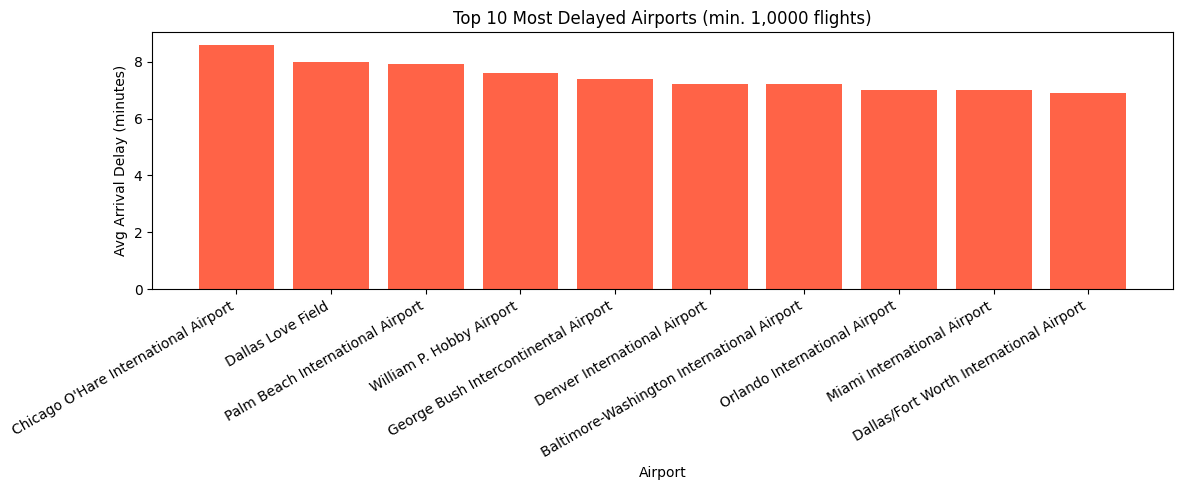

In [11]:
airport_counts = flights_clean['ORIGIN_AIRPORT'].value_counts()
busy_airports = airport_counts[airport_counts >= 10000].index

airport_delay = flights_clean[flights_clean['ORIGIN_AIRPORT'].isin(busy_airports)]
airport_delay = airport_delay.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().round(1).reset_index()
airport_delay = airport_delay.merge(airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE')
airport_delay = airport_delay.sort_values('ARRIVAL_DELAY', ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(airport_delay['AIRPORT'], airport_delay['ARRIVAL_DELAY'], color='tomato')
plt.title('Top 10 Most Delayed Airports (min. 1,0000 flights)')
plt.xlabel('Airport')
plt.ylabel('Avg Arrival Delay (minutes)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Insight:** Among major airports (10,000+ flights), Chicago O'Hare and Dallas airports are the most delayed. O'Hare's high traffic volume and Chicago's unpredictable weather make it a chronic bottleneck. Both Dallas airports appearing in the top 10 suggests a regional infrastructure issue.


### Finding 5: Evening Flights Are Delayed the Most


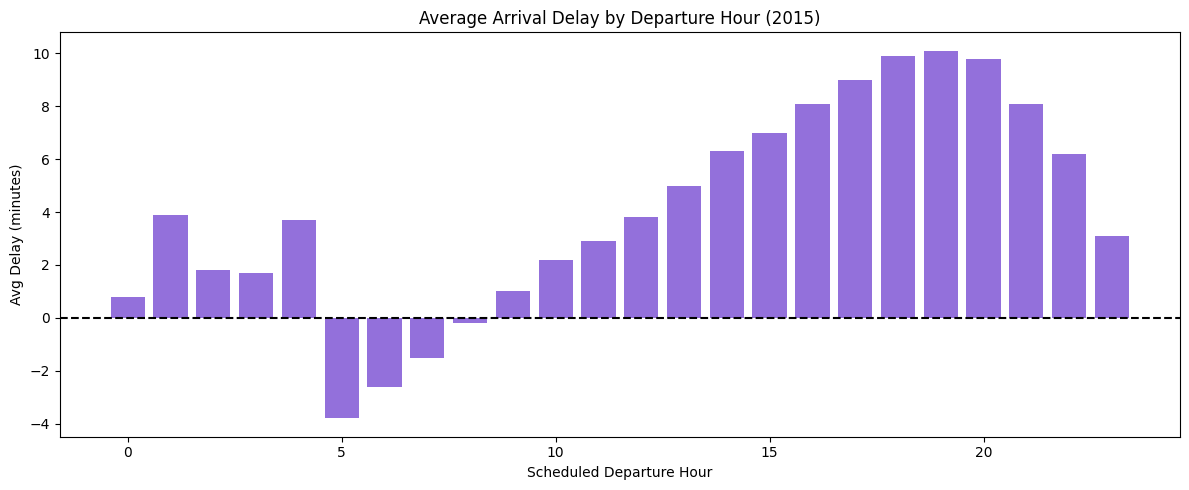

In [12]:
flights_clean['HOUR'] = flights_clean['SCHEDULED_DEPARTURE'] // 100

hourly_delay = flights_clean.groupby('HOUR')['ARRIVAL_DELAY'].mean().round(1)

plt.figure(figsize=(12, 5))
plt.bar(hourly_delay.index, hourly_delay.values, color='mediumpurple')
plt.title('Average Arrival Delay by Departure Hour (2015)')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Avg Delay (minutes)')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


**Insight:** Early morning flights (5-8am) actually arrive early on average — they're the first flights of the day with no prior delays to inherit. By evening, accumulated delays across the day push average delays to 10+ minutes. The practical advice: book the first flight of the day.


### Finding 6: Regional Airlines Have the Highest Cancellation Rates



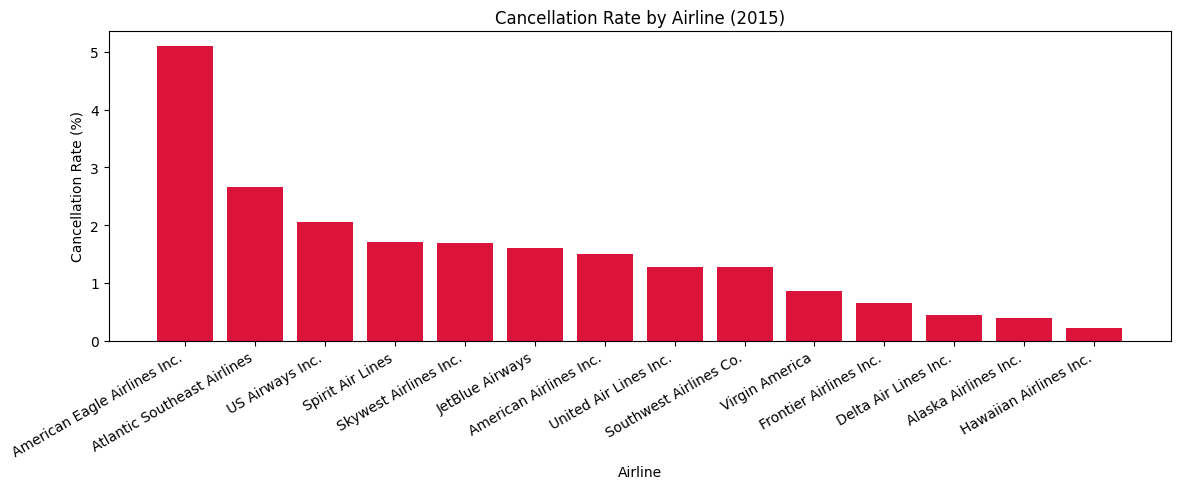

In [14]:
cancel_rate = flights.groupby('AIRLINE').agg(
    total=('CANCELLED', 'count'),
    cancelled=('CANCELLED', 'sum')
).reset_index()
cancel_rate['cancel_rate'] = (cancel_rate['cancelled'] / cancel_rate['total'] * 100).round(2)
cancel_rate = cancel_rate.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')
cancel_rate = cancel_rate.sort_values('cancel_rate', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(cancel_rate['AIRLINE_y'], cancel_rate['cancel_rate'], color='crimson')
plt.title('Cancellation Rate by Airline (2015)')
plt.xlabel('Airline')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


 **Insight:** American Eagle and Atlantic Southeast — both regional carriers — have the highest cancellation rates (5.1% and 2.7%). Regional airlines operate smaller planes on shorter routes and are more vulnerable to weather and crew shortages. Hawaiian Airlines has the lowest rate at just 0.2%, benefiting from stable weather and simpler routes.


---

## Section 4: SQL Analysis


In [17]:
import sqlite3

_flights = pd.read_csv('/Users/siheng/Documents/workspace/flights.csv', low_memory=False)
_airlines = pd.read_csv('/Users/siheng/Documents/workspace/airlines.csv')
_airports = pd.read_csv('/Users/siheng/Documents/workspace/airports.csv')

conn = sqlite3.connect(':memory:')
_flights.to_sql('flights', conn, index=False, if_exists='replace')
_airlines.to_sql('airlines', conn, index=False, if_exists='replace')
_airports.to_sql('airports', conn, index=False, if_exists='replace')

print('SQL database ready!')
print(f'flights: {len(_flights):,} rows')


SQL database ready!
flights: 5,819,079 rows


### SQL Query 1: Which airlines have the most delayed flights?


In [18]:
result1 = pd.read_sql("""
    SELECT a.AIRLINE, 
           ROUND(AVG(f.ARRIVAL_DELAY), 1) AS avg_delay,
           COUNT(*) AS total_flights
    FROM flights f
    JOIN airlines a ON f.AIRLINE = a.IATA_CODE
    WHERE f.CANCELLED = 0 AND f.ARRIVAL_DELAY IS NOT NULL
    GROUP BY a.AIRLINE
    ORDER BY avg_delay DESC
""", conn)

result1


,AIRLINE,avg_delay,total_flights
0,Spirit Air Lines,14.5,115193
1,Frontier Airlines Inc.,12.5,90090
2,JetBlue Airways,6.7,262042
3,Atlantic Southeast Airlines,6.6,554752
4,American Eagle Airlines Inc.,6.5,278791
5,Skywest Airlines Inc.,5.8,576814
6,United Air Lines Inc.,5.4,507762
7,Virgin America,4.7,61248
8,Southwest Airlines Co.,4.4,1242403
9,US Airways Inc.,3.7,194223


### SQL Query 2: Which states have above-average arrival delays? (Subquery)


In [20]:
result2 = pd.read_sql("""
    SELECT ap.STATE,
           ROUND(AVG(f.ARRIVAL_DELAY), 1) AS avg_delay,
           COUNT(*) AS total_flights
    FROM flights f
    JOIN airports ap ON f.ORIGIN_AIRPORT = ap.IATA_CODE
    WHERE f.CANCELLED = 0 AND f.ARRIVAL_DELAY IS NOT NULL
    GROUP BY ap.STATE
    HAVING COUNT(*) >= 10000
    AND AVG(f.ARRIVAL_DELAY) > (
        SELECT AVG(ARRIVAL_DELAY) 
        FROM flights 
        WHERE CANCELLED = 0 AND ARRIVAL_DELAY IS NOT NULL
    )
    ORDER BY avg_delay DESC
    LIMIT 10
""", conn)

result2


,STATE,avg_delay,total_flights
0,AR,8.1,21923
1,IL,8.0,369479
2,MD,7.2,84329
3,CO,7.2,212126
4,IA,7.1,16728
5,TX,6.7,616518
6,KS,6.1,10633
7,NV,5.9,145305
8,LA,5.8,63944
9,NC,5.6,144394


### SQL Query 3: Which route has the worst average delay for each airline? (CTE)


In [21]:
result3 = pd.read_sql("""
    WITH route_delay AS (
        SELECT AIRLINE,
               ORIGIN_AIRPORT || ' → ' || DESTINATION_AIRPORT AS route,
               ROUND(AVG(ARRIVAL_DELAY), 1) AS avg_delay,
               COUNT(*) AS total_flights
        FROM flights
        WHERE CANCELLED = 0 AND ARRIVAL_DELAY IS NOT NULL
        GROUP BY AIRLINE, ORIGIN_AIRPORT, DESTINATION_AIRPORT
        HAVING COUNT(*) >= 100
    ),
    worst_route AS (
        SELECT AIRLINE, MAX(avg_delay) AS max_delay
        FROM route_delay
        GROUP BY AIRLINE
    )
    SELECT r.AIRLINE, a.AIRLINE AS airline_name, 
           r.route, r.avg_delay, r.total_flights
    FROM route_delay r
    JOIN worst_route w ON r.AIRLINE = w.AIRLINE AND r.avg_delay = w.max_delay
    JOIN airlines a ON r.AIRLINE = a.IATA_CODE
    ORDER BY r.avg_delay DESC
    LIMIT 10
""", conn)

result3


,AIRLINE,airline_name,route,avg_delay,total_flights
0,NK,Spirit Air Lines,ATL → LAS,52.6,206
1,F9,Frontier Airlines Inc.,PHL → ORD,44.7,260
2,MQ,American Eagle Airlines Inc.,ASE → DFW,40.0,262
3,AA,American Airlines Inc.,JFK → EGE,38.0,105
4,UA,United Air Lines Inc.,RDU → EWR,37.6,179
5,OO,Skywest Airlines Inc.,JAX → ORD,31.1,172
6,EV,Atlantic Southeast Airlines,OMA → MSP,30.4,116
7,B6,JetBlue Airways,SRQ → LGA,29.4,326
8,DL,Delta Air Lines Inc.,SFO → LAX,27.6,1352
9,WN,Southwest Airlines Co.,MCO → RIC,24.2,332


## Section 5: Business Recommendations

Based on the analysis above, here are three actionable recommendations:

### 1. Book Early Morning Flights to Minimize Delays
Flights departing before 8am arrive early on average, while evening flights (after 3pm) average 10+ minutes late. 
**Recommendation:** Travelers should book the first flight of the day, especially on busy routes. Airlines should incentivize early departures with lower fares to distribute traffic more evenly throughout the day.

### 2. Spirit and Frontier Must Improve Operational Reliability
Spirit averages 14.5 minutes late per flight — nearly 3x worse than Alaska Airlines (-1.0 min). 
**Recommendation:** Both airlines should audit their scheduling practices and ground crew efficiency. Reducing late aircraft cascades (the #1 delay cause overall) would have the biggest impact on on-time performance.

### 3. Address Chronic Delays at Chicago O'Hare and Texas Airports
O'Hare is the most delayed major airport, and both Dallas airports appear in the top 10. Illinois and Texas are also the highest-delay states. 
**Recommendation:** Airlines should build more buffer time into schedules for flights through these hubs, and the FAA should prioritize air traffic control upgrades at O'Hare.


In [24]:
# Summary 1: Average delay by airline
airline_summary = flights_clean.groupby('AIRLINE').agg(
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    total_flights=('ARRIVAL_DELAY', 'count')
).round(1).reset_index()
airline_summary = airline_summary.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')
airline_summary.to_csv('/Users/siheng/Documents/workspace/summary_airline.csv', index=False)

# Summary 2: Average delay by month
month_summary = flights_clean.groupby('MONTH')['ARRIVAL_DELAY'].mean().round(1).reset_index()
month_summary.to_csv('/Users/siheng/Documents/workspace/summary_month.csv', index=False)

# Summary 3: Delay causes
cause_summary = flights_clean[['AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','AIR_SYSTEM_DELAY','WEATHER_DELAY','SECURITY_DELAY']].mean().round(2).reset_index()
cause_summary.columns = ['cause', 'avg_minutes']
cause_summary.to_csv('/Users/siheng/Documents/workspace/summary_causes.csv', index=False)

print('Done! 3 summary files created.')


Done! 3 summary files created.
